In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
repred = pd.read_csv('../Data/RePred_Activity_merged.csv')
clinvarMis = pd.read_csv('../Data/clinvar_missense.csv')

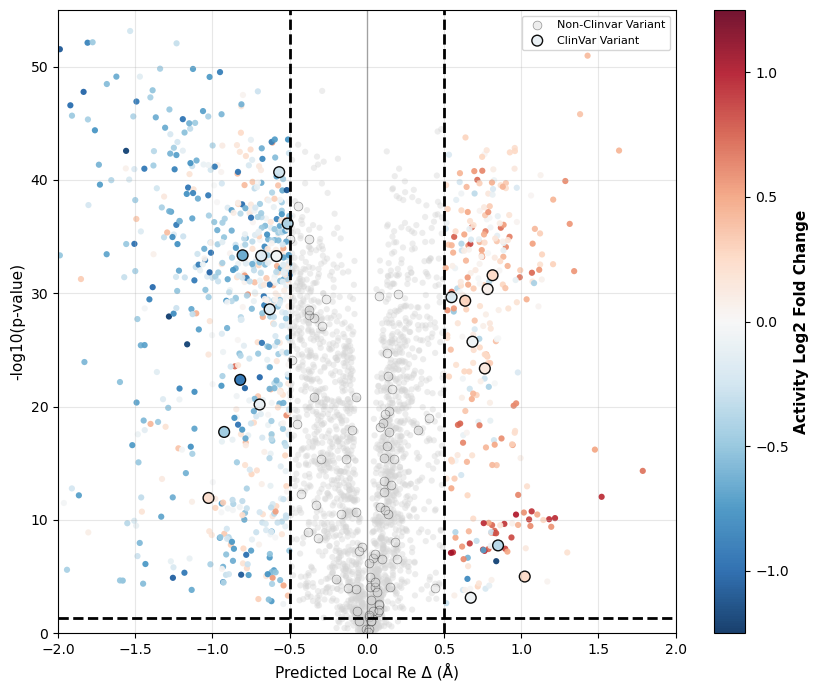

In [3]:
# Transform normalized activity score to log2 fold change
# score of 0.5 -> log2(0.5) = -1
# score of 1.0 -> log2(1.0) = 0
# score of 2.0 -> log2(2.0) = 1
repred['activity_log2FC'] = np.log2(repred['normalized_activity_score_mean'])

# Create volcano plot
plt.figure(figsize=(8.5, 7))

# Create color array - grey for non-significant or small delta Re
colors = []
for idx, row in repred.iterrows():
    pval = row['mut_vs_wt_Re_pval_50']
    delta_re = row['mut_vs_wt_Re_delta_50']
    activity = row['activity_log2FC']
    
    # Grey if not significant OR if delta Re is between -0.5 and 0.5
    if pval < 1.3 or (-0.5 <= delta_re <= 0.5):
        colors.append('lightgrey')
    else:
        colors.append(activity)

# Convert to array for plotting
colors_array = np.array(colors, dtype=object)

# Separate significant and non-significant points
sig_mask = np.array([c != 'lightgrey' for c in colors])
non_sig_mask = ~sig_mask

# Check which mutations are in ClinVar
clinvar_mutations = set(clinvarMis['Protein change'])
repred['is_clinvar'] = repred['mutation'].isin(clinvar_mutations)

# Plot non-significant points (grey)
# Separate ClinVar and non-ClinVar
non_sig_clinvar = non_sig_mask & repred['is_clinvar']
non_sig_non_clinvar = non_sig_mask & ~repred['is_clinvar']

plt.scatter(repred.loc[non_sig_non_clinvar, 'mut_vs_wt_Re_delta_50'], 
           repred.loc[non_sig_non_clinvar, 'mut_vs_wt_Re_pval_50'],
           c='lightgrey',
           alpha=0.4, 
           s=20, 
           edgecolors='none')

plt.scatter(repred.loc[non_sig_clinvar, 'mut_vs_wt_Re_delta_50'], 
           repred.loc[non_sig_clinvar, 'mut_vs_wt_Re_pval_50'],
           c='lightgrey',
           alpha=0.4, 
           s=40,  # Double size for ClinVar
           edgecolors='black',
           linewidth=0.5,
           label='Non-Clinvar Variant')

# Plot significant points (colored by activity)
if sig_mask.sum() > 0:
    # Separate ClinVar and non-ClinVar significant points
    sig_clinvar = sig_mask & repred['is_clinvar']
    sig_non_clinvar = sig_mask & ~repred['is_clinvar']

    # Plot non-ClinVar significant points
    if sig_non_clinvar.sum() > 0:
        activity_colors = repred.loc[sig_non_clinvar, 'activity_log2FC']
        scatter = plt.scatter(repred.loc[sig_non_clinvar, 'mut_vs_wt_Re_delta_50'], 
                             repred.loc[sig_non_clinvar, 'mut_vs_wt_Re_pval_50'],
                             c=activity_colors, 
                             cmap='RdBu_r',
                             alpha=0.92, 
                             s=20, 
                             edgecolors='none',
                             vmin=-1.25,
                             vmax=1.25)
    
    # Plot ClinVar significant points (larger)
    if sig_clinvar.sum() > 0:
        activity_colors_clinvar = repred.loc[sig_clinvar, 'activity_log2FC']
        scatter2 = plt.scatter(repred.loc[sig_clinvar, 'mut_vs_wt_Re_delta_50'], 
                              repred.loc[sig_clinvar, 'mut_vs_wt_Re_pval_50'],
                              c=activity_colors_clinvar, 
                              cmap='RdBu_r',
                              alpha=0.95, 
                              s=60,  # Double size for ClinVar
                              edgecolors='black',
                              linewidth=1,
                              vmin=-1.25,
                              vmax=1.25,
                              label='ClinVar Variant')
    
    # Add colorbar (use whichever scatter exists)
    if sig_non_clinvar.sum() > 0:
        cbar = plt.colorbar(scatter)
    elif sig_clinvar.sum() > 0:
        cbar = plt.colorbar(scatter2)
    cbar.set_label('Activity Log2 Fold Change', fontsize=11, fontweight='bold')

# Add threshold lines
plt.axhline(y=1.3, color='black', linestyle='--', linewidth=2)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
plt.axvline(x=-.5, color='black', linestyle='--', linewidth=2, alpha=1)
plt.axvline(x=.5, color='black', linestyle='--', linewidth=2, alpha=1)

plt.ylim(0, 55)
plt.xlim(-2, 2)

# Labels
plt.xlabel('Predicted Local Re Δ (Å)', fontsize=11)
plt.ylabel('-log10(p-value)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8, loc='upper right')

plt.tight_layout()

plt.savefig('../Graphs/Fig3/RePred_vs_activity_volcano.svg')

In [4]:
# Create change_cat column
repred['change_cat'] = 'No Change'
repred.loc[(repred['mut_vs_wt_Re_pval_50'] > 1.3) & (repred['mut_vs_wt_Re_delta_50'] > 0.5), 'change_cat'] = 'Re Δ > 0.5 Å'
repred.loc[(repred['mut_vs_wt_Re_pval_50'] > 1.3) & (repred['mut_vs_wt_Re_delta_50'] < -.5), 'change_cat'] = 'Re Δ < -0.5 Å'

# Print summary
print("Re Change Categories:")
print(repred['change_cat'].value_counts())

Re Change Categories:
change_cat
No Change        2183
Re Δ < -0.5 Å     682
Re Δ > 0.5 Å      300
Name: count, dtype: int64


/var/folders/s5/pmcccnjn3xscf5d6crplwgx40000gn/T/ipykernel_93704/1955428835.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['', '-1', '', '0', '', '1'], fontsize=10)


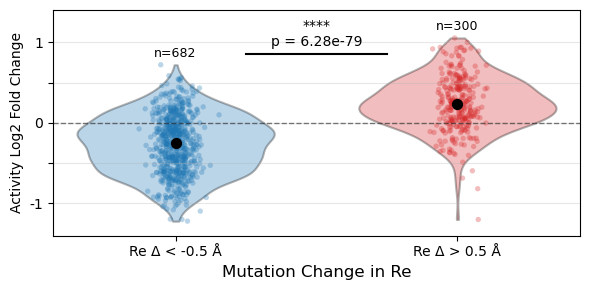

In [5]:
# Filter data with activity scores
plot_data = repred[repred['activity_log2FC'].notna()].copy()

# Create figure with single subplot
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

# Filter to only significant changes
sig_only = plot_data[plot_data['change_cat'] != 'No Change'].copy()

# Calculate means and SEMs
category_order_sig = ['Re Δ < -0.5 Å', 'Re Δ > 0.5 Å']
median_sig = [sig_only[sig_only['change_cat'] == cat]['activity_log2FC'].median() 
             for cat in category_order_sig]

# Create violin plot with transparency
colors_sig = ['#1f77b4', '#d62728']  # Blue for increase, red for decrease
parts = ax.violinplot([sig_only[sig_only['change_cat'] == cat]['activity_log2FC'].values 
                       for cat in category_order_sig],
                      positions=range(len(category_order_sig)),
                      showmeans=False, showmedians=False, showextrema=False,
                      widths=0.7)

# Color the violins with transparency
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_sig[i])
    pc.set_alpha(0.3)  # More transparent
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

# Plot individual data points with jitter
np.random.seed(42)  # For reproducibility
for i, cat in enumerate(category_order_sig):
    data = sig_only[sig_only['change_cat'] == cat]['activity_log2FC'].values
    # Add jitter to x positions
    jitter = np.random.normal(0, 0.04, size=len(data))
    ax.scatter(np.ones(len(data)) * i + jitter, data,
              alpha=0.3, s=15, color=colors_sig[i], edgecolors='none')

# Add median marker
for i in range(len(category_order_sig)):
    ax.scatter(i, median_sig[i], color='black', s=50, zorder=10)

# Perform t-test
decrease_data = sig_only[sig_only['change_cat'] == 'Re Δ < -0.5 Å']['activity_log2FC']
increase_data = sig_only[sig_only['change_cat'] == 'Re Δ > 0.5 Å']['activity_log2FC']
t_stat, p_value = stats.ttest_ind(decrease_data, increase_data)

# Add significance annotation
y_max = max([sig_only[sig_only['change_cat'] == cat]['activity_log2FC'].max() 
             for cat in category_order_sig])
y_pos = y_max
ax.plot([.25, .75], [y_pos - .2, y_pos - .2], 'k-', linewidth=1.5)
sig_text = f'p = {p_value:.4f}' if p_value >= 0.001 else f'p = {p_value:.2e}'
if p_value < 0.0001:
    sig_stars = '****'
elif p_value < 0.01:
    sig_stars = '**'
elif p_value < 0.05:
    sig_stars = '*'
elif p_value < .001:
    sig_stars = '***'
else:
    sig_stars = 'ns'
ax.text(0.5, y_pos - .1, f'{sig_stars}\n{sig_text}', ha='center', fontsize=10)

# Add horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Limits
ax.set_ylim(-1.4, 1.4)

# Labels and formatting
ax.set_xlabel('Mutation Change in Re', fontsize=12)
ax.set_xticks(range(len(category_order_sig)))
ax.set_xticklabels(category_order_sig, fontsize=10)
ax.set_yticks([-1, 0, 1], minor = [-.5, .5])
ax.set_yticklabels(['', '-1', '', '0', '', '1'], fontsize=10)
ax.set_ylabel('Activity Log2 Fold Change', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add sample sizes above violins
for i, cat in enumerate(category_order_sig):
    n = len(sig_only[sig_only['change_cat'] == cat])
    y_max_cat = sig_only[sig_only['change_cat'] == cat]['activity_log2FC'].max()
    ax.text(i, y_max_cat + .1, f'n={n}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../Graphs/Fig3/RePred_vs_activity_violin.svg')